***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.6 时间平均、频率平均与展宽](9_6_averaging_and_smearing.ipynb)
    * 下一节： [9.x 延伸阅读与后续实践方向](9_x_further_reading_and_workflow.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.7 谱线数据处理：continuum subtraction、数据立方体与矩图

谱线实践和连续谱实践最根本的差别在于：我们不再只关心“总带宽里平均有多亮”，而要保留频率轴上的细结构，并把它解释成速度、柱密度和运动学信息。

一个最常见的基础流程通常包括：

- 先识别 line-free channels；
- 在频率轴上估计并去除连续谱；
- 得到 line-only data cube；
- 浏览 channel map；
- 用阈值 mask 构造 moment 0 / moment 1 图；
- 从积分谱线中估计系统速度与线宽。

这一节用一个完全自包含的合成 H I 风格数据立方体演示整个过程。它并不替代真实的 `uvcontsub`、`tclean` cube mode 或 `immoments`，但足以把最核心的实践判断串起来。


***


In [2]:
c_kms = 299792.458
rest_freq_ghz = 1.42040575


def normalized_gaussian(x, y, x0, y0, sigma_x, sigma_y):
    profile = np.exp(
        -0.5 * (((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2)
    )
    profile /= profile.sum()
    return profile


def make_beam(npix=56, sigma_pix=1.6):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    beam = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    beam /= beam.max()
    return beam


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel))
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


npix = 56
cell_arcsec = 1.5
coords = (np.arange(npix) - npix // 2) * cell_arcsec
x_grid, y_grid = np.meshgrid(coords, coords)

vel_kms = np.linspace(-90.0, 90.0, 49)
freqs_ghz = rest_freq_ghz * (1.0 - vel_kms / c_kms)
dv = np.abs(vel_kms[1] - vel_kms[0])

continuum_map = np.zeros((npix, npix))
center = np.argmin(np.abs(coords - 0.0))
continuum_map[center, center] += 0.36
continuum_map += 0.14 * normalized_gaussian(x_grid, y_grid, 16.0, -12.0, 3.0, 2.5)

line_surface_brightness = (
    0.95 * normalized_gaussian(x_grid, y_grid, 3.0, -2.0, 8.0, 5.0)
    + 0.28 * normalized_gaussian(x_grid, y_grid, -10.0, 8.0, 4.0, 3.0)
)
velocity_field = 8.0 + 1.8 * x_grid
sigma_v = 7.0

line_cube = np.zeros((vel_kms.size, npix, npix))
for ci, vel in enumerate(vel_kms):
    line_cube[ci] = line_surface_brightness * np.exp(
        -0.5 * ((vel - velocity_field) / sigma_v) ** 2
    )

beam = make_beam(npix=npix, sigma_pix=1.7)
beam_area_pix = beam.sum()

restored_cube = np.zeros_like(line_cube)
for ci in range(vel_kms.size):
    restored_cube[ci] = fft_convolve_same(continuum_map + line_cube[ci], beam)

restored_cube += 0.0035 * RNG.normal(size=restored_cube.shape)

line_free = np.abs(vel_kms) > 45.0
continuum_est = restored_cube[line_free].mean(axis=0)
cube_sub = restored_cube - continuum_est[None, :, :]

noise_rms = 1.4826 * np.median(
    np.abs(cube_sub[line_free] - np.median(cube_sub[line_free]))
)
source_aperture = ((x_grid - 3.0) ** 2 + (y_grid + 2.0) ** 2) < 14.0**2
spectrum_raw = restored_cube[:, source_aperture].sum(axis=1) / beam_area_pix
spectrum_line = cube_sub[:, source_aperture].sum(axis=1) / beam_area_pix


### 9.7.1 先识别 line-free channels，再做连续谱扣除

谱线处理里最容易犯的一个错误，是没有先想清楚哪些通道可以视为“只有连续谱，没有谱线”。若 line-free channels 选错，continuum subtraction 本身就会把谱线结构吃掉或扭曲。

下面先看积分谱，再看基于 line-free channels 的简单连续谱估计。这里采用的是最简单的频率均值法；真实处理里更常见的是在可见度域做 `uvcontsub`，并允许低阶多项式拟合。


line-free 通道数 = 24 / 49
continuum-subtracted cube 的噪声 RMS ≈ 0.0034 Jy/beam


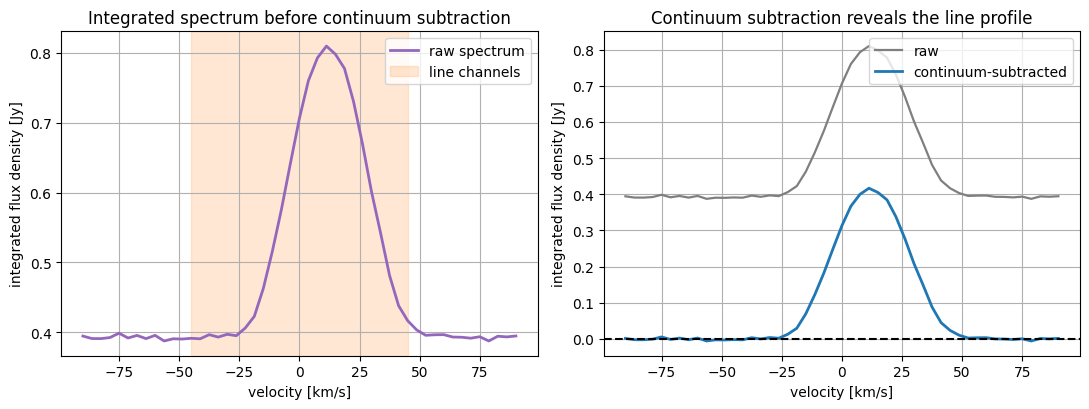

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(vel_kms, spectrum_raw, color="tab:purple", lw=2.0, label="raw spectrum")
axes[0].axvspan(vel_kms[~line_free][0], vel_kms[~line_free][-1], color="tab:orange", alpha=0.18, label="line channels")
axes[0].set_xlabel("velocity [km/s]")
axes[0].set_ylabel("integrated flux density [Jy]")
axes[0].set_title("Integrated spectrum before continuum subtraction")
axes[0].legend(loc="upper right")

axes[1].plot(vel_kms, spectrum_raw, color="tab:gray", lw=1.6, label="raw")
axes[1].plot(vel_kms, spectrum_line, color="tab:blue", lw=2.0, label="continuum-subtracted")
axes[1].axhline(0.0, color="black", ls="--")
axes[1].set_xlabel("velocity [km/s]")
axes[1].set_ylabel("integrated flux density [Jy]")
axes[1].set_title("Continuum subtraction reveals the line profile")
axes[1].legend(loc="upper right")

plt.tight_layout()
print(f"line-free 通道数 = {line_free.sum()} / {vel_kms.size}")
print(f"continuum-subtracted cube 的噪声 RMS ≈ {noise_rms:.4f} Jy/beam")


这一步之后，数据结构才真正变成了“谱线数据立方体”。此时后续所有 channel map、矩图和线宽测量，都应基于 continuum-subtracted cube，而不是原始含连续谱的数据。


### 9.7.2 浏览 channel map：谱线不是一张图，而是一组随速度变化的切片

连续谱图像只有二维，而谱线数据的基本对象是三维立方体。最直接的入口就是 channel map：观察不同速度通道上，发射在空间上如何移动、增强或减弱。


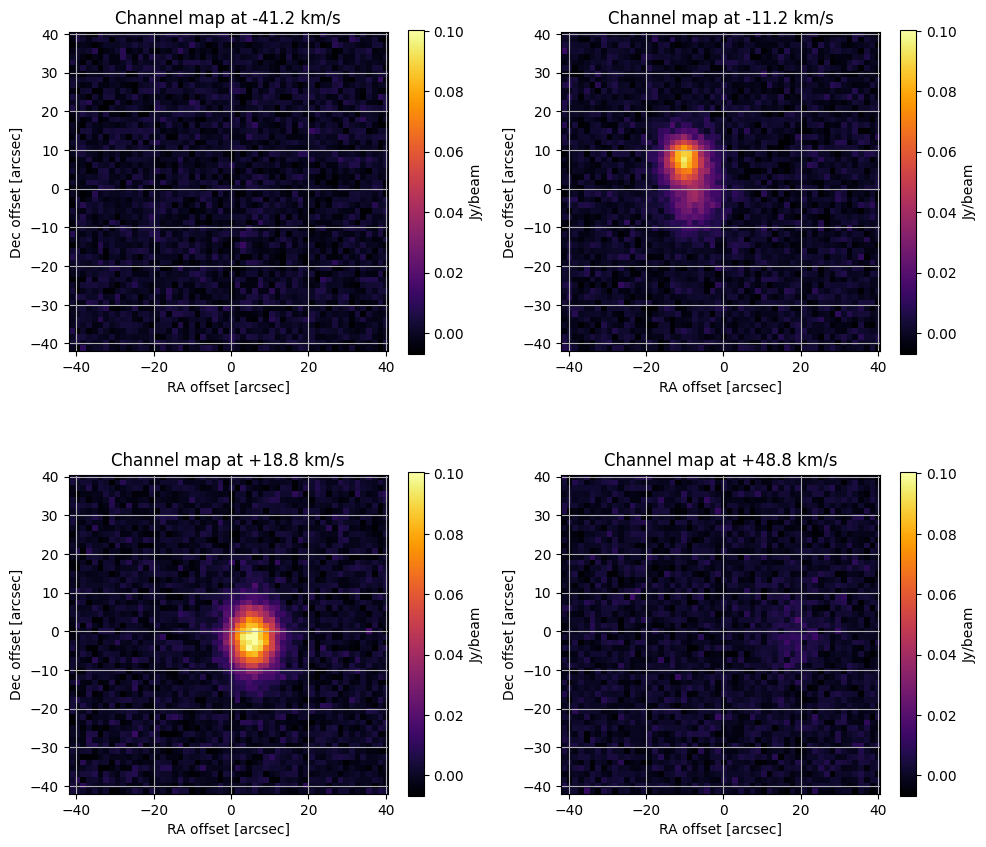

In [4]:
channel_targets = [-40.0, -10.0, 20.0, 50.0]
channel_indices = [np.argmin(np.abs(vel_kms - target)) for target in channel_targets]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, idx in zip(axes.ravel(), channel_indices):
    im = ax.imshow(
        cube_sub[idx],
        origin="lower",
        extent=[coords[0], coords[-1], coords[0], coords[-1]],
        cmap="inferno",
        vmin=-2.0 * noise_rms,
        vmax=np.max(cube_sub[channel_indices]) * 0.95,
    )
    ax.set_title(f"Channel map at {vel_kms[idx]:+.1f} km/s")
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Jy/beam")

plt.tight_layout()


这些切片能直接回答一个很重要的问题：发射在不同速度通道上是否沿空间方向系统移动。若答案是肯定的，那么 moment 1 图通常就会呈现出清晰的速度梯度。


### 9.7.3 用阈值 mask 构造 moment 0 与 moment 1 图

若不加筛选就直接对整立方体积分，噪声会严重污染矩图。因此实践里一般会先构造一个 mask，只保留显著探测到发射的像素。

这里使用一个最简单的 3-sigma 阈值 mask。真实数据处理中，也常会结合空间平滑、频率平滑或源寻找结果来构造更稳健的掩膜。


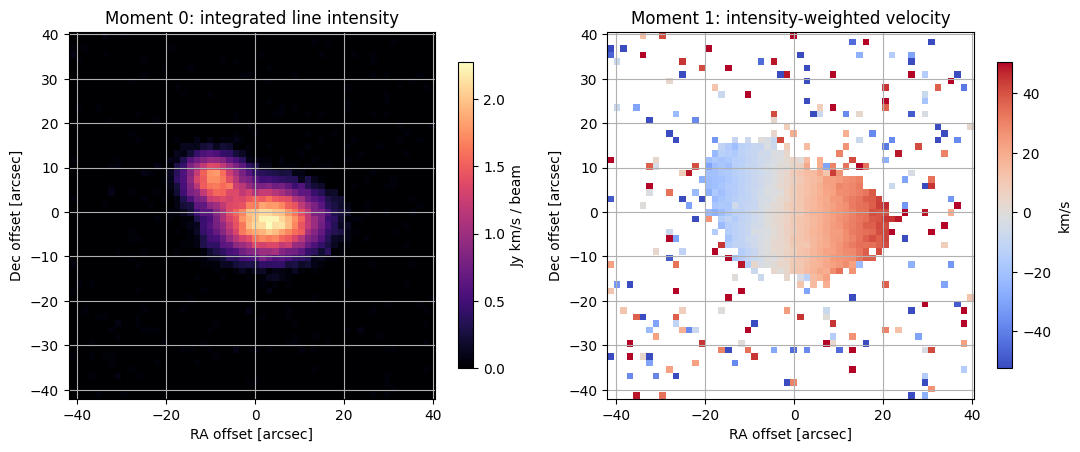

In [5]:
mask = cube_sub > (3.0 * noise_rms)
masked_cube = np.where(mask, cube_sub, 0.0)

moment0 = masked_cube.sum(axis=0) * dv
weight_sum = masked_cube.sum(axis=0)
weighted_velocity = (masked_cube * vel_kms[:, None, None]).sum(axis=0)
moment1 = np.full_like(weight_sum, np.nan, dtype=float)
np.divide(weighted_velocity, weight_sum, out=moment1, where=weight_sum > 0.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

im0 = axes[0].imshow(
    moment0,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="magma",
)
axes[0].set_title("Moment 0: integrated line intensity")
axes[0].set_xlabel("RA offset [arcsec]")
axes[0].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im0, ax=axes[0], shrink=0.82, label="Jy km/s / beam")

im1 = axes[1].imshow(
    moment1,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="coolwarm",
    vmin=np.nanpercentile(moment1, 5),
    vmax=np.nanpercentile(moment1, 95),
)
axes[1].set_title("Moment 1: intensity-weighted velocity")
axes[1].set_xlabel("RA offset [arcsec]")
axes[1].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im1, ax=axes[1], shrink=0.82, label="km/s")

plt.tight_layout()


这里的 moment 0 图近似对应积分强度图，而 moment 1 图则给出了速度场的最基础入口。和第 1.7 节讨论的一样，真正值得关注的不是“有一条线”，而是这条线如何把空间结构和运动学结构耦合起来。


### 9.7.4 做一个基础谱线测量：系统速度与等效线宽

下面基于 aperture 内的积分谱线，估计两个最常见的量：

- **系统速度**：谱线强度加权的平均速度；
- **等效 FWHM**：把谱线二阶矩换算成一个高斯等效线宽。

这些量并不替代完整的线型拟合，但已经足以说明“谱线不仅有强度，还有速度信息和宽度信息”。


系统速度 ≈ 11.96 km/s
高斯等效 FWHM ≈ 34.34 km/s
积分线通量 ≈ 15.43 Jy km/s


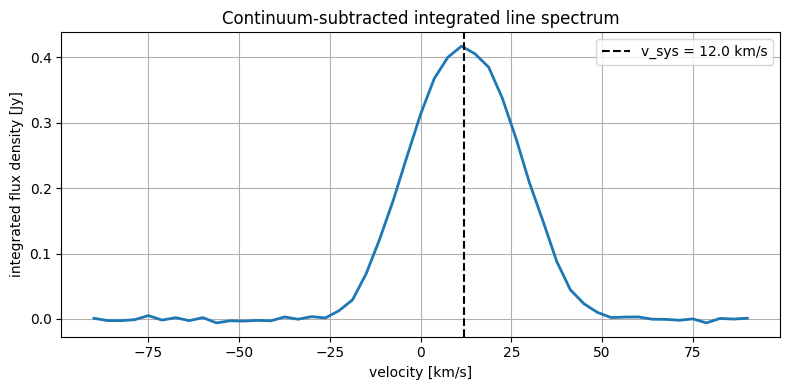

In [6]:
positive_spec = np.clip(spectrum_line, a_min=0.0, a_max=None)
systemic_velocity = np.sum(vel_kms * positive_spec) / np.sum(positive_spec)
sigma_line = np.sqrt(np.sum(positive_spec * (vel_kms - systemic_velocity) ** 2) / np.sum(positive_spec))
fwhm_equiv = 2.355 * sigma_line
integrated_flux = np.sum(positive_spec) * dv

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(vel_kms, spectrum_line, color="tab:blue", lw=2.0)
ax.axvline(systemic_velocity, color="black", ls="--", label=f"v_sys = {systemic_velocity:.1f} km/s")
ax.set_xlabel("velocity [km/s]")
ax.set_ylabel("integrated flux density [Jy]")
ax.set_title("Continuum-subtracted integrated line spectrum")
ax.legend(loc="upper right")
plt.tight_layout()

print(f"系统速度 ≈ {systemic_velocity:.2f} km/s")
print(f"高斯等效 FWHM ≈ {fwhm_equiv:.2f} km/s")
print(f"积分线通量 ≈ {integrated_flux:.2f} Jy km/s")


### 9.7.5 与真实软件流程的对应

若把这个练习映射到真实软件环境，最常见的谱线处理链大致是：

- `plotms` / `plotbandpass`：先确认 bandpass 与 line-free channels；
- `uvcontsub`：在可见度域做连续谱扣除；
- `tclean`（cube mode）：逐通道成像得到 data cube；
- `immoments`：构造矩图；
- `specfit` 或自定义测量：估计速度、线宽和积分通量。

这里最重要的专业判断是：**谱线处理不只是“连续谱成像再多一维”。** 它需要更谨慎的频谱基线处理、更明确的 line-free 选择，以及对矩图噪声偏差的持续警惕。
